Now Import libraters


In [ ]:
import pandas as pd
import numpy as np 
import matplotlib. pyplot as plt
import seaborn as sns 
print('Libraries imported successfully ')


Load the dataset

In [ ]:
df = pd.read_csv('ecommerce_sales_analytics.csv')
print('Dataset loaded successfully')

Dataset loaded successfully


Initial Data Inspection

In [ ]:
df.head()

,Transacion Id,Date,customer_id,product_category,Gender,region,quantity,Price per unit,discount,payment_method,delivery_days,customer_rating,Total Amount,Age
0,10001,01-01-2022,1102,Beauty,Male,South,7,373.65,0.28,Wallet,10,4.7,1883.20,33
1,10002,01-02-2022,1435,Clothing,Male,South,7,47.74,0.09,Card,6,3.9,304.10,48
2,10003,01-03-2022,1860,Beauty,Female,East,3,311.28,0.31,COD,6,2.5,644.35,73
3,10004,01-04-2022,1270,Electronics,Male,West,5,524.47,0.02,Wallet,6,1.6,2569.90,31
4,10005,01-05-2022,1106,Clothing,Female,West,5,139.87,0.33,Wallet,4,4.9,468.56,41


In [42]:
print("Number of rows and columns:")
print(df.shape)

Number of rows and columns:
(1000, 14)


In [27]:
print("Data types:")
print(df.dtypes)

Data types:
Transacion Id         int64
Date                    str
customer_id           int64
product_category        str
Gender                  str
region                  str
quantity              int64
Price per unit      float64
discount            float64
payment_method          str
delivery_days         int64
customer_rating     float64
Total Amount        float64
Age                   int64
dtype: object


In [43]:
print("missing values:")
print(df.isnull().sum())

missing values:
Transacion Id       0
Date                0
customer_id         0
product_category    0
Gender              0
region              0
quantity            0
Price per unit      0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
Total Amount        0
Age                 0
dtype: int64


In [29]:
df.describe()

,Transacion Id,customer_id,quantity,Price per unit,discount,delivery_days,customer_rating,Total Amount,Age
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,10500.500000,1504.555000,4.085000,303.232230,0.183300,6.130000,2.963600,1011.094600,35.791000
std,288.819436,290.125045,2.022341,171.366646,0.100006,3.104632,1.156647,825.565893,12.934861
min,10001.000000,1000.000000,1.000000,15.780000,0.000000,1.000000,1.000000,12.830000,18.000000
25%,10250.750000,1242.750000,2.000000,152.625000,0.100000,4.000000,2.000000,345.105000,26.000000
50%,10500.500000,1506.000000,4.000000,296.850000,0.190000,6.000000,3.000000,799.865000,33.000000
75%,10750.250000,1758.000000,6.000000,451.762500,0.270000,9.000000,3.900000,1485.480000,43.250000
max,11000.000000,1998.000000,7.000000,599.320000,0.350000,11.000000,5.000000,4119.330000,75.000000


Time Service Analysis
Monthly Sales Trend
firstly.convert the date column to
datetime,calculate monthly sales,convert the period
to timestamp for plottng,now plot monthly sales
trend.

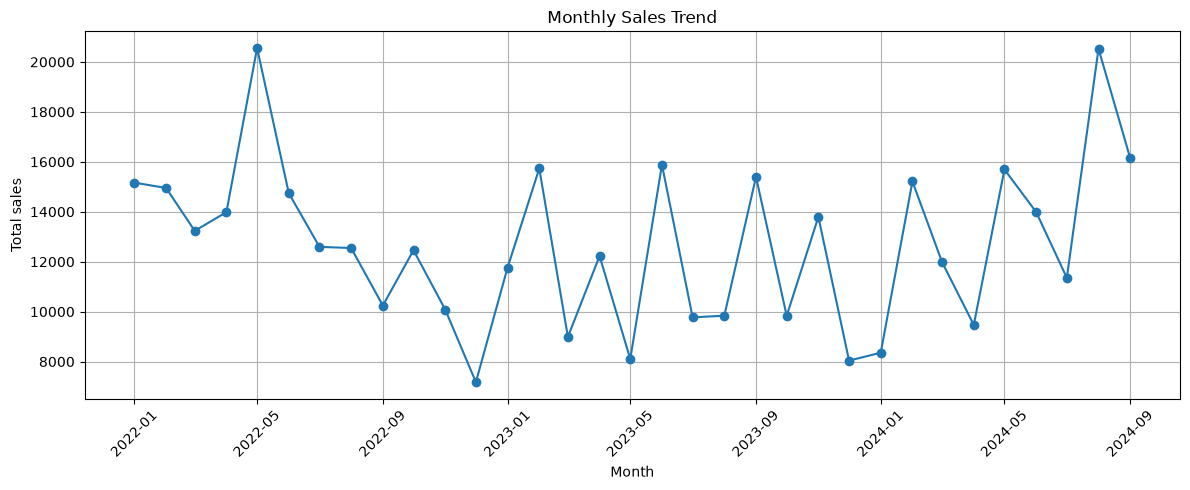

In [44]:
df['Date'] = pd.to_datetime(df['Date'],errors='coerce')
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Total Amount'].sum()
monthly_sales.index=monthly_sales.index.to_timestamp()
plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index,monthly_sales.values,marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel( 'Month')
plt.ylabel('Total sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()




Observaton: 
from the above chat we can observe monthly sales are fluctuating throughout the period.
overall the chat sales trend shows ups and downs with no consistent increase or decrease


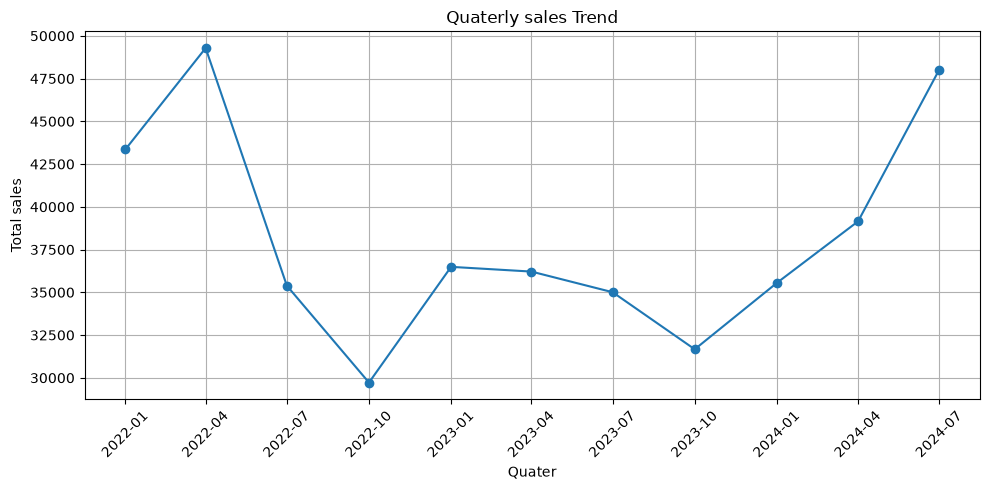

In [45]:
quaterly_sales = df.groupby(df['Date'].dt.to_period('Q'))['Total Amount'].sum()
quaterly_sales.index = quaterly_sales.index.to_timestamp()
plt.figure(figsize=(10,5))
plt.plot(quaterly_sales.index,quaterly_sales.values,marker='o')
plt.title( 'Quaterly sales Trend')
plt.xlabel( 'Quater')
plt.ylabel( 'Total sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Observaton:
Quaterly sales show fluctuations,with the highest sales recorded Q2 - 2022 (49000) 
Q2 -2022 (47000)
Sales started improving again in 2024,showing a positve growth trend.

Customers Demographic Analysis 
Customers Age Group

In [46]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['Transacion Id', 'Date', 'customer_id', 'product_category', 'Gender', 'region', 'quantity', 'Price per unit', 'discount', 'payment_method', 'delivery_days', 'customer_rating', 'Total Amount', 'Age']


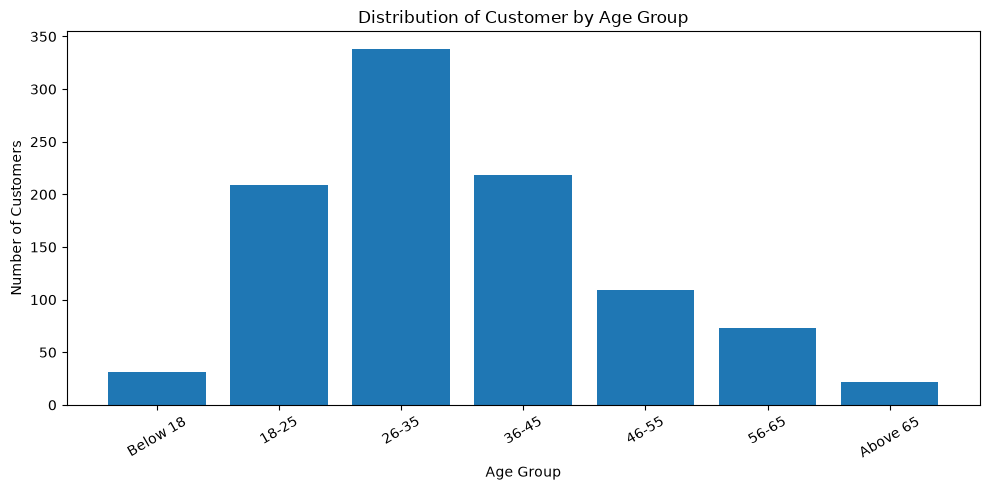

In [47]:

bins = [0,18,25,35,45,55,65,100]
labels = ['Below 18','18-25','26-35','36-45','46-55','56-65','Above 65'] 
df['Age Group'] = pd.cut(df['Age'],bins=bins,labels=labels,include_lowest=True)
age_group_counts = df['Age Group'].value_counts().sort_index()
plt.figure(figsize=(10,5))
plt.bar(age_group_counts.index.astype(str),age_group_counts.values)
plt.title('Distribution of Customer by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


Observation : from the above distribution we can observe that how the customers are spread across different age groups.

Gender Breakdown

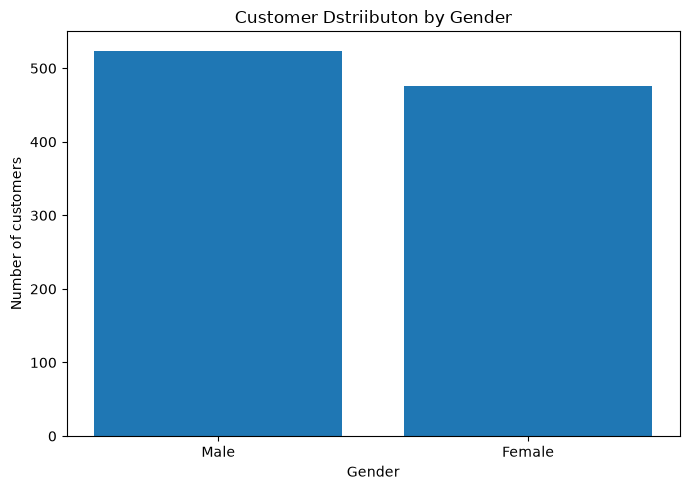

In [48]:
gender_counts = df['Gender'].value_counts()
plt.figure(figsize=(7,5))
plt.bar(gender_counts.index,gender_counts.values)
plt.title('Customer Dstriibuton by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of customers')
plt.tight_layout()
plt.show()

Observation: From the above bar chart shows Customers Dstributon by Gender.
Male customers are the slightly higher than female customers

Product Analysis
Note:The Dataset which I have consider doesn't contain  the product name columns.It has only product category.

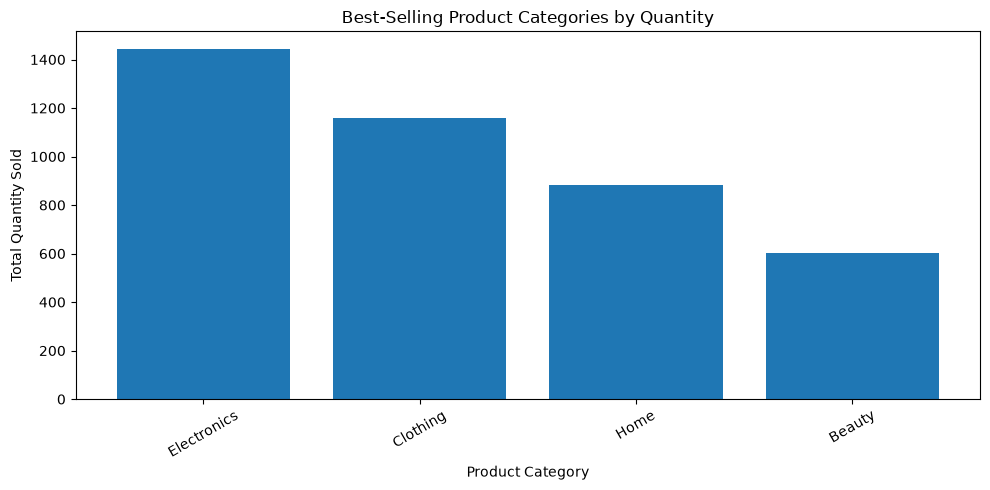

In [35]:
category_quantity = (df.groupby('product_category')['quantity'].sum().sort_values(ascending=False).head())
plt.figure(figsize=(10,5))
plt.bar(category_quantity.index,category_quantity.values)
plt.title('Best-Selling Product Categories by Quantity')
plt.xlabel('Product Category')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

From the Above bar chart  shows the best & selling product categories based on the quantity goods can the sell electronics are the highest sales ,and  customers have a stronger preference  for the electronics and the clothing etc....


Revenue by Product Category 

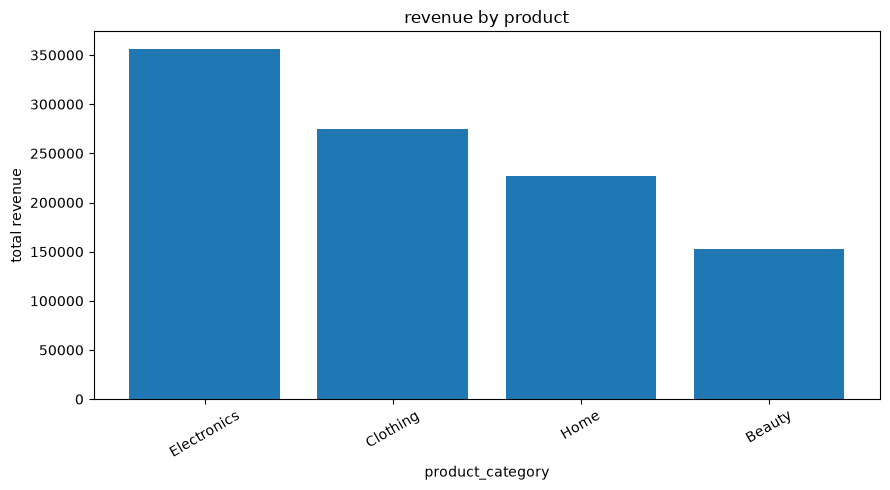

In [36]:
category_revenue = (df.groupby('product_category')['Total Amount'].sum().sort_values(ascending=False))
plt.figure(figsize=(9,5))
plt.bar(category_revenue.index,category_revenue.values)
plt.title('revenue by product')
plt.xlabel('product_category')
plt.ylabel('total revenue')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Observation: From the above chart we can observe that the Total Revenue  generated by the different product categories with the Electronics has the hight revenue at the approximately from the following  products.Electronics is the most strongest performance of the bar chart

Correlation Heatmap

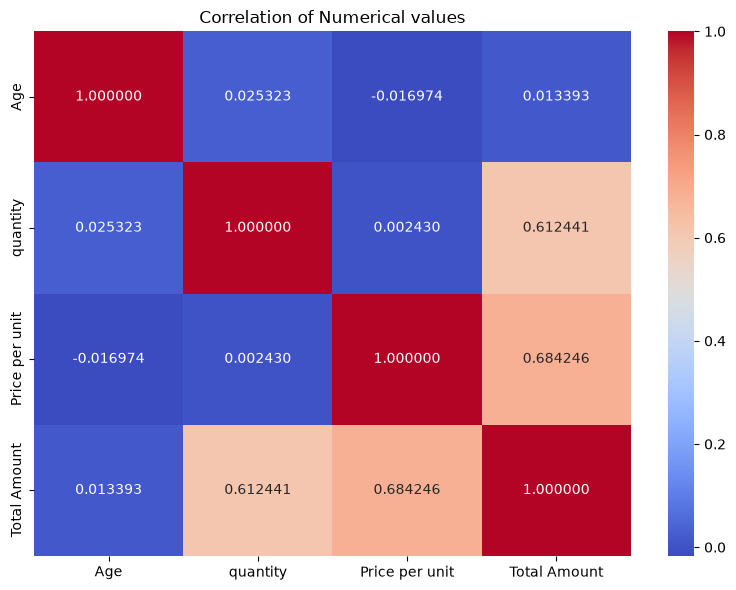

In [37]:
numerical_columns = ['Age','quantity','Price per unit','Total Amount']
correlation_matrix = df[numerical_columns].corr()
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',fmt='2f')
plt.title('Correlation of Numerical values')
plt.tight_layout()
plt.show()

Obeservation: The Correlation heatmap shows the relation between the numerical values. Age and the Total Amount shows a nagative correlation (around the -0.62)
Total Amount is the most strongly related to the Quantity ,Age and the price per unit 
The Age and the Quantity have a very weak position correlation (around 0.03)

Additional Visualization 
Spending by Age Group 

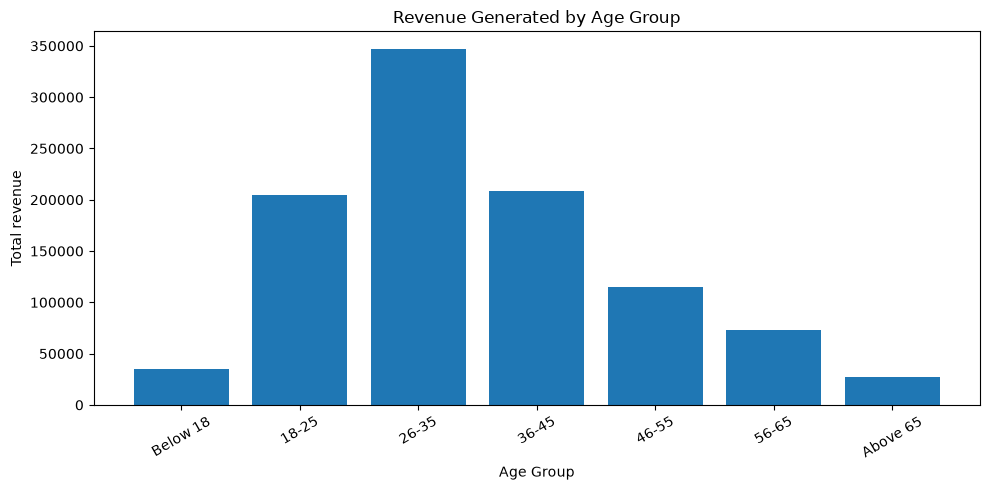

In [50]:
age_revenue  = (df.groupby('Age Group',observed=True)['Total Amount'].sum())
plt.figure(figsize=(10,5))
plt.bar(age_revenue.index.astype(str),age_revenue.values)
plt.title('Revenue Generated by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total revenue')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


Observation:It provides additional information on the customer behavior.This can be help to the identify the customer segments with spending contribution 
The customer age generates the highest revenue and the revenue s considerly lower for customer and major contributors to total revenue

Actionable Recommendations:

1. Focus marketing efforts on the some age group persons it was generates the   highest revenue 
2 . strengthen the Sales During Low performing periods.
3 . Use data-driven marketing and product startegies

 Conclusion : The Exploratory Data Analysis the business should focus on retaiining the high value of the customers improving targeted marketing and the introducing personalized offers for the age group persons the strategies can help increase customer sales and over all the revenue.